In [2]:
from pathlib import Path
import duckdb
import pandas as pd

class DataHubReader:
    def __init__(self, db_name="yahoo_finance.db"):
        """
        Stellt Verbindung zur DuckDB her.
        Erwartet dieselbe Ordnerstruktur wie DataHub.
        """
        base_path = Path.cwd()
        db_path = base_path.parent.parent / "data" / "01_raw" / "yahoo" / db_name

        if not db_path.exists():
            raise FileNotFoundError(f"Datenbank nicht gefunden: {db_path}")

        self.con = duckdb.connect(str(db_path))

    def _fetch_table(self, table_name: str) -> pd.DataFrame:
        """Generische Methode zum Laden einer Tabelle."""
        return self.con.execute(f"SELECT * FROM {table_name}").df()

    def get_financials(self) -> pd.DataFrame:
        """Yahoo Finance Financials"""
        return self._fetch_table("bronze_financials")

    def get_wikidata(self) -> pd.DataFrame:
        """Wikidata Unternehmensdaten"""
        return self._fetch_table("bronze_wikidata")

    def get_GMD(self) -> pd.DataFrame:
        """Global Macro Database"""
        return self._fetch_table("bronze_gmd")

    def get_interest(self) -> pd.DataFrame:
        """IMF Zinsdaten"""
        return self._fetch_table("bronze_interest")

    def get_commodity(self) -> pd.DataFrame:
        """IMF Commodity Daten"""
        return self._fetch_table("bronze_commodities")

    def close(self):
        """Schließt die Datenbankverbindung."""
        self.con.close()

In [2]:
reader = DataHubReader()
df = reader.get_financials()
df


,ticker,date,affiliation,item_description,value,unit,ingested_at
0,AAL,2025-12-31,balance_sheet,TreasurySharesNumber,NaN,USD,2026-03-16 22:27:31.783029
1,AAL,2025-12-31,balance_sheet,OrdinarySharesNumber,6.603011e+08,USD,2026-03-16 22:27:31.783029
2,AAL,2025-12-31,balance_sheet,ShareIssued,6.603011e+08,USD,2026-03-16 22:27:31.783029
3,AAL,2025-12-31,balance_sheet,NetDebt,2.896700e+10,USD,2026-03-16 22:27:31.783029
4,AAL,2025-12-31,balance_sheet,TotalDebt,3.688400e+10,USD,2026-03-16 22:27:31.783029
...,...,...,...,...,...,...,...
7072445,ZUC.MI,2026-03-01,price_history,Close,6.300000e-01,EUR,2026-03-17 02:08:14.275681
7072446,ZUC.MI,2026-03-01,price_history,High,7.000000e-01,EUR,2026-03-17 02:08:14.275681
7072447,ZUC.MI,2026-03-01,price_history,Low,6.100000e-01,EUR,2026-03-17 02:08:14.275681
7072448,ZUC.MI,2026-03-01,price_history,Open,6.920000e-01,EUR,2026-03-17 02:08:14.275681


In [3]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import pandas as pd
import numpy as np

@dataclass
class YahooFinanceValidator:
    """
    Validiert und harmonisiert Yahoo-Financials-Daten.

    Erwartete Spalten:
    ticker | date | affiliation | item_description | value | ingested_at
    """

    ticker_col: str = "ticker"
    date_col: str = "date"
    affiliation_col: str = "affiliation"
    item_description_col: str = "item_description"
    value_col: str = "value"
    ingested_at_col: str = "ingested_at"

    def validate(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Führt die Typ-Harmonisierung auf allen relevanten Spalten durch.
        Nicht konvertierbare Werte werden zu NaN / NaT.
        """
        self._validate_required_columns(df)

        out = df.copy()

        out[self.ticker_col] = self._to_string_series(out[self.ticker_col])
        out[self.date_col] = self._to_timestamp_series(out[self.date_col])
        out[self.affiliation_col] = self._to_string_series(out[self.affiliation_col])
        out[self.item_description_col] = self._to_string_series(out[self.item_description_col])
        out[self.value_col] = self._to_float_series(out[self.value_col])

        if self.ingested_at_col in out.columns:
            out[self.ingested_at_col] = self._to_timestamp_series(out[self.ingested_at_col])

        return out

    def _validate_required_columns(self, df: pd.DataFrame) -> None:
        required = {
            self.ticker_col,
            self.date_col,
            self.affiliation_col,
            self.item_description_col,
            self.value_col,
            self.ingested_at_col,
        }
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"Fehlende Spalten im DataFrame: {sorted(missing)}")

    @staticmethod
    def _to_string_series(series: pd.Series) -> pd.Series:
        """
        Wandelt Werte in Strings um.
        Falls ein Wert nicht sinnvoll konvertierbar ist, wird <NA> gesetzt.

        Hinweis:
        Fast alles ist in Python zu str(...) konvertierbar.
        Problematische Fälle wie None/NaN/leere Strings werden als fehlend markiert.
        """
        def convert(value: object) -> Optional[str]:
            if pd.isna(value):
                return pd.NA
            try:
                text = str(value).strip()
                if text == "":
                    return pd.NA
                return text
            except Exception:
                return pd.NA

        return series.map(convert).astype("string")

    @staticmethod
    def _to_timestamp_series(series: pd.Series) -> pd.Series:
        """
        Wandelt Werte in pandas Timestamps um.
        Nicht konvertierbare Werte werden zu NaT.
        """
        return pd.to_datetime(series, errors="coerce")

    @staticmethod
    def _to_float_series(series: pd.Series) -> pd.Series:
        """
        Wandelt Werte in float64 um.
        Nicht konvertierbare Werte werden zu NaN.

        float64 ist für GNN/ML-Pipelines meist die richtige Wahl.
        """
        numeric = pd.to_numeric(series, errors="coerce")
        return numeric.astype("float64")

    def report_invalid_counts(self, df_before: pd.DataFrame, df_after: pd.DataFrame) -> pd.DataFrame:
        """
        Erstellt einen kleinen Report, wie viele fehlende Werte nach der Validierung
        in den relevanten Spalten vorliegen.
        """
        cols = [
            self.ticker_col,
            self.date_col,
            self.affiliation_col,
            self.item_description_col,
            self.value_col,
            self.ingested_at_col,
        ]

        rows = []
        for col in cols:
            before_missing = df_before[col].isna().sum()
            after_missing = df_after[col].isna().sum()
            rows.append({
                "column": col,
                "missing_before": int(before_missing),
                "missing_after": int(after_missing),
                "new_missing_created": int(after_missing - before_missing),
            })

        return pd.DataFrame(rows)

In [4]:
df_after = YahooFinanceValidator().validate(df)

In [5]:
YahooFinanceValidator().report_invalid_counts(df, df_after)

,column,missing_before,missing_after,new_missing_created
0,ticker,0,0,0
1,date,0,0,0
2,affiliation,0,0,0
3,item_description,0,0,0
4,value,661329,661329,0
5,ingested_at,0,0,0


In [6]:
from __future__ import annotations

from typing import Optional, Sequence
import pandas as pd


class YahooFinanceDuplicateChecker:
    """
    Prüft und behandelt Duplikate in Yahoo-Financials-Long-Format.

    Standard-Naturschlüssel:
    ["ticker", "date", "affiliation", "item_description"]
    """

    DEFAULT_SUBSET = ["ticker", "date", "affiliation", "item_description"]

    def __init__(self, subset: Optional[Sequence[str]] = None):
        self.subset = list(subset) if subset is not None else self.DEFAULT_SUBSET.copy()

    def _validate_subset(self, df: pd.DataFrame, subset: Optional[Sequence[str]] = None) -> list[str]:
        use_subset = list(subset) if subset is not None else self.subset
        missing = [col for col in use_subset if col not in df.columns]
        if missing:
            raise ValueError(f"Fehlende Spalten für Duplicate-Check: {missing}")
        return use_subset

    def find_exact_duplicates(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Gibt alle Zeilen zurück, die exakte Duplikate kompletter Zeilen sind.
        Alle betroffenen Zeilen werden zurückgegeben (keep=False).
        """
        mask = df.duplicated(keep=False)
        return df.loc[mask].copy()

    def find_key_duplicates(
        self,
        df: pd.DataFrame,
        subset: Optional[Sequence[str]] = None
    ) -> pd.DataFrame:
        """
        Gibt alle Zeilen zurück, die bezüglich des natürlichen Schlüssels dupliziert sind.

        Standardmäßig:
        ["ticker", "date", "affiliation", "item_description"]

        Beispiel:
        Zwei Zeilen mit gleichem ticker/date/affiliation/item_description,
        aber unterschiedlichem value oder ingested_at, werden hier gefunden.
        """
        use_subset = self._validate_subset(df, subset)
        mask = df.duplicated(subset=use_subset, keep=False)
        return df.loc[mask].copy()

    def drop_duplicates(
        self,
        df: pd.DataFrame,
        subset: Optional[Sequence[str]] = None,
        keep: str = "first"
    ) -> pd.DataFrame:
        """
        Entfernt Duplikate anhand des natürlichen Schlüssels oder eines übergebenen Subsets.

        keep:
        - "first": erste Zeile behalten
        - "last": letzte Zeile behalten
        - False: alle Duplikat-Gruppen komplett entfernen
        """
        use_subset = self._validate_subset(df, subset)
        return df.drop_duplicates(subset=use_subset, keep=keep).copy()

    def duplicate_summary(
        self,
        df: pd.DataFrame,
        subset: Optional[Sequence[str]] = None
    ) -> pd.DataFrame:
        """
        Gibt eine kleine Zusammenfassung über exakte und Schlüssel-Duplikate zurück.
        """
        use_subset = self._validate_subset(df, subset)

        exact_mask = df.duplicated(keep=False)
        key_mask = df.duplicated(subset=use_subset, keep=False)

        summary = pd.DataFrame(
            {
                "metric": [
                    "total_rows",
                    "exact_duplicate_rows",
                    "key_duplicate_rows",
                    "exact_duplicate_groups",
                    "key_duplicate_groups",
                ],
                "value": [
                    len(df),
                    int(exact_mask.sum()),
                    int(key_mask.sum()),
                    int(df.loc[exact_mask].drop_duplicates().shape[0]) if exact_mask.any() else 0,
                    int(
                        df.loc[key_mask, use_subset]
                        .drop_duplicates()
                        .shape[0]
                    ) if key_mask.any() else 0,
                ],
            }
        )
        return summary

In [7]:
checker = YahooFinanceDuplicateChecker()

In [8]:
exact_dups = checker.find_exact_duplicates(df_after)
print(exact_dups.head())

Empty DataFrame
Columns: [ticker, date, affiliation, item_description, value, unit, ingested_at]
Index: []


In [9]:
key_dups = checker.find_key_duplicates(df_after)
print(key_dups.head())

    ticker       date         affiliation    item_description        value  \
844    AAL 2024-09-21  shares_outstanding  shares_outstanding  656704000.0   
845    AAL 2024-09-21  shares_outstanding  shares_outstanding  663572992.0   
849    AAL 2024-09-28  shares_outstanding  shares_outstanding  656704000.0   
850    AAL 2024-09-28  shares_outstanding  shares_outstanding  670622016.0   
860    AAL 2024-10-24  shares_outstanding  shares_outstanding  656704000.0   

       unit                ingested_at  
844  shares 2026-03-16 22:27:31.783029  
845  shares 2026-03-16 22:27:31.783029  
849  shares 2026-03-16 22:27:31.783029  
850  shares 2026-03-16 22:27:31.783029  
860  shares 2026-03-16 22:27:31.783029  


In [11]:
import pandas as pd
import matplotlib.pyplot as plt


class YahooFinanceCoverageAnalyzer:
    def ticker_summary(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Erstellt eine einfache Übersicht pro Ticker:
        - Gesamtzahl Beobachtungen
        - Anzahl Zeitpunkte
        - Anzahl Features
        """
        summary = (
            df.groupby("ticker")
            .agg(
                total_observations=("ticker", "size"),
                n_periods=("date", "nunique"),
                n_features=("item_description", "nunique"),
            )
            .reset_index()
        )
        print(df["ticker"].nunique())
        return summary

    def count_periods_per_ticker(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Zählt die Anzahl unterschiedlicher Zeitpunkte pro Ticker.
        """
        return (
            df.groupby("ticker")["date"]
            .nunique()
            .reset_index(name="n_periods")
        )

    def count_features_per_ticker(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Zählt die Anzahl unterschiedlicher Features pro Ticker.
        """
        return (
            df.groupby("ticker")["item_description"]
            .nunique()
            .reset_index(name="n_features")
        )

    def filter_min_periods(self, df: pd.DataFrame, min_periods: int = 3) -> pd.DataFrame:
        """
        Behält nur Ticker mit mindestens min_periods unterschiedlichen Zeitpunkten.
        """
        valid_tickers = (
            df.groupby("ticker")["date"]
            .nunique()
            .loc[lambda x: x >= min_periods]
            .index
        )
        return df[df["ticker"].isin(valid_tickers)].copy()

    def filter_min_features(self, df: pd.DataFrame, min_features: int = 10) -> pd.DataFrame:
        """
        Behält nur Ticker mit mindestens min_features unterschiedlichen Features.
        """
        valid_tickers = (
            df.groupby("ticker")["item_description"]
            .nunique()
            .loc[lambda x: x >= min_features]
            .index
        )
        return df[df["ticker"].isin(valid_tickers)].copy()

    def filter_min_total_observations(self, df: pd.DataFrame, min_obs: int = 50) -> pd.DataFrame:
        """
        Behält nur Ticker mit mindestens min_obs Gesamtbeobachtungen.
        """
        valid_tickers = (
            df.groupby("ticker")
            .size()
            .loc[lambda x: x >= min_obs]
            .index
        )
        return df[df["ticker"].isin(valid_tickers)].copy()
    def recommend_thresholds(self, df: pd.DataFrame, quantile: float = 0.25) -> dict:
        """
        Bestimmt sinnvolle Mindestwerte basierend auf einem Quantil der Coverage.

        Beispiel:
        quantile=0.25 → untere 25% der Firmen werden als schlecht
        dokumentiert betrachtet.

        Returns:
        {
            "min_features": ...,
            "min_periods": ...,
            "min_obs": ...
        }
        """

        summary = self.ticker_summary(df)

        thresholds = {
            "min_features": int(summary["n_features"].quantile(quantile)),
            "min_periods": int(summary["n_periods"].quantile(quantile)),
            "min_obs": int(summary["total_observations"].quantile(quantile)),
        }

        return thresholds

    def filter_by_quantile(self, df: pd.DataFrame, quantile: float = 0.25) -> pd.DataFrame:
        """
        Filtert den DataFrame automatisch anhand der empfohlenen Quantilschwellen.
        """

        thresholds = self.recommend_thresholds(df, quantile)

        df = self.filter_min_features(df, thresholds["min_features"])
        #df = self.filter_min_periods(df, thresholds["min_periods"])
        #df = self.filter_min_total_observations(df, thresholds["min_obs"])

        return df
        
    def plot_coverage_distributions(self, df: pd.DataFrame):
        """
        Plottet die Verteilungen von:
        - Anzahl Features pro Ticker
        - Anzahl Perioden pro Ticker
        - Gesamtbeobachtungen pro Ticker
        """

        summary = self.ticker_summary(df)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].hist(summary["n_features"], bins=50)
        axes[0].set_title("Features pro Ticker")
        axes[0].set_xlabel("Anzahl Features")
        axes[0].set_ylabel("Anzahl Firmen")

        axes[1].hist(summary["n_periods"], bins=50)
        axes[1].set_title("Perioden pro Ticker")
        axes[1].set_xlabel("Anzahl Perioden")

        axes[2].hist(summary["total_observations"], bins=50)
        axes[2].set_title("Gesamtbeobachtungen pro Ticker")
        axes[2].set_xlabel("Anzahl Observations")

        plt.tight_layout()
        plt.show()

5790
5790


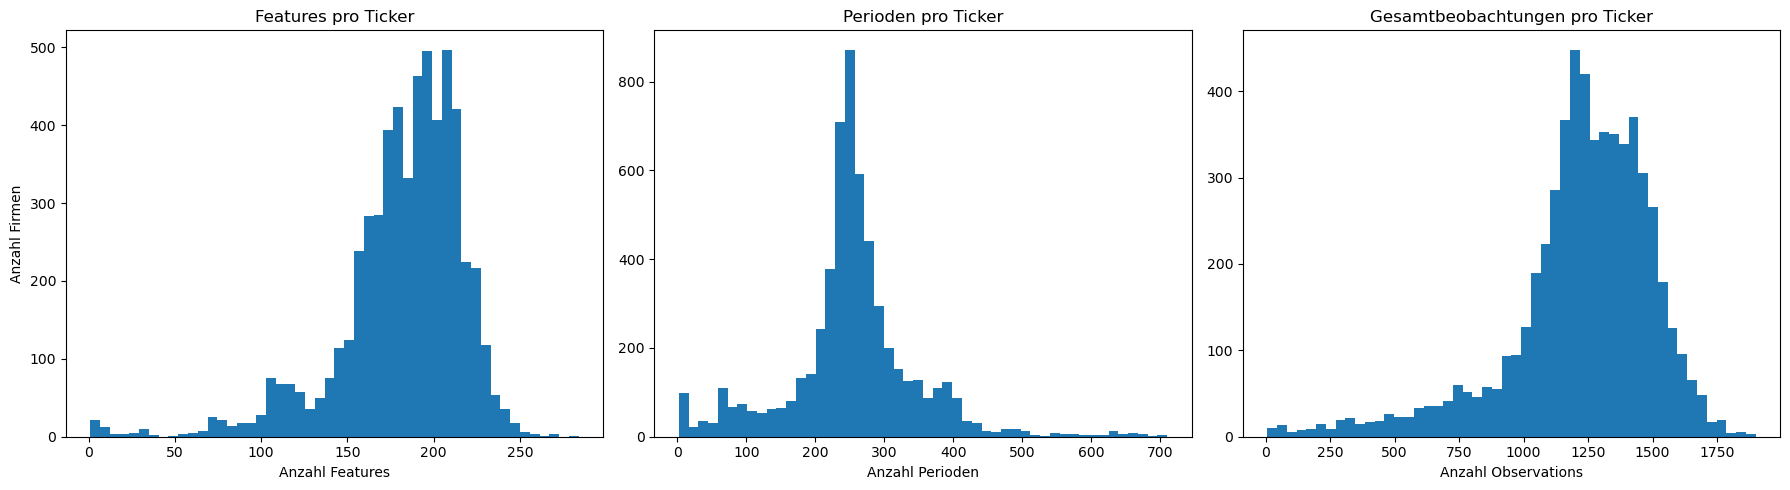

7072450
6346286
4923


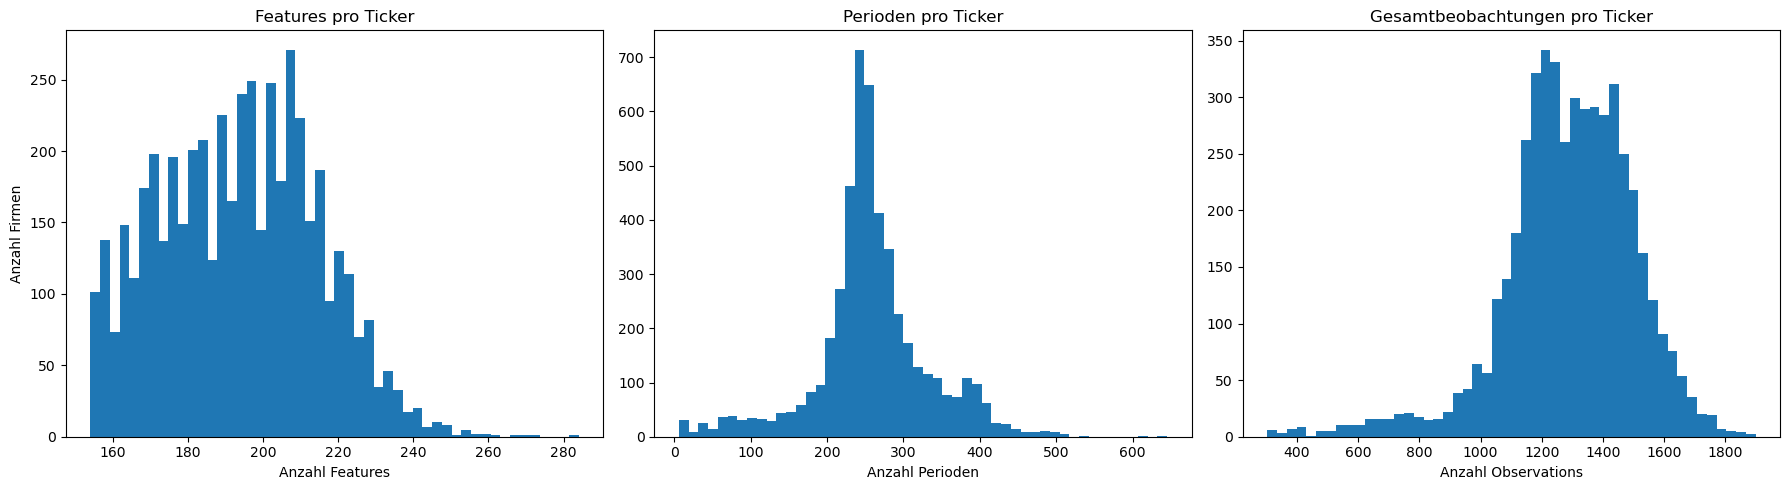

In [12]:
analyzer = YahooFinanceCoverageAnalyzer()

df_filtered = analyzer.filter_by_quantile(df, 0.15)
analyzer.plot_coverage_distributions(df)
print(len(df))
print(len(df_filtered))
analyzer.plot_coverage_distributions(df_filtered)

In [14]:
harmonizer = CurrencyHarmonizer()
harmonizer.run()

df_silver = harmonizer.get_silver_financials_usd()
harmonizer.close()
df_silver



,ticker,date,affiliation,item_description,original_value,original_unit,fx_rate,value_usd,unit
0,2020.OL,2019-11-11,dividends,dividends,5.000000e-01,NOK,NaN,NaN,USD
1,2020.OL,2019-12-06,dividends,dividends,7.742368e-01,NOK,NaN,NaN,USD
2,2020.OL,2020-01-14,dividends,dividends,3.871184e-01,NOK,NaN,NaN,USD
3,2020.OL,2020-02-13,dividends,dividends,2.903388e-01,NOK,NaN,NaN,USD
4,2020.OL,2020-08-17,dividends,dividends,9.677960e-02,NOK,NaN,NaN,USD
...,...,...,...,...,...,...,...,...,...
7072445,ZYME,2026-03-10,shares_outstanding,shares_outstanding,7.430279e+07,shares,NaN,7.430279e+07,shares
7072446,ZYME,2026-03-16,major_holders,insidersPercentHeld,1.260000e-02,percent,NaN,1.260000e-02,percent
7072447,ZYME,2026-03-16,major_holders,institutionsCount,2.910000e+02,percent,NaN,2.910000e+02,percent
7072448,ZYME,2026-03-16,major_holders,institutionsFloatPercentHeld,9.989801e-01,percent,NaN,9.989801e-01,percent


In [40]:
from pathlib import Path
import duckdb
import pandas as pd


class CurrencyHarmonizer:
    def __init__(self, db_name="yahoo_finance.db"):
        base_path = Path.cwd()
        db_path = base_path.parent.parent / "data" / "01_raw" / "yahoo" / db_name
        self.con = duckdb.connect(str(db_path))

    def close(self):
        self.con.close()

    def load_bronze_financials(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT
                ticker,
                date,
                affiliation,
                item_description,
                value,
                unit
            FROM bronze_financials
        """).df()

    def load_fx_rates(self) -> pd.DataFrame:
        return self.con.execute("""
            SELECT
                base_currency,
                quote_currency,
                date,
                rate
            FROM bronze_fx_rates
        """).df()

    def harmonize_to_usd(self) -> pd.DataFrame:
        """
        Harmonisiert Werte aus bronze_financials nach USD.

        Regeln:
        - unit == 'USD' -> USD_Value = value
        - unit in ('percent', 'shares') -> USD_Value = value
        - sonst -> USD_Value = value * FX-Rate
        - falls für den Tag kein FX-Match existiert:
          verwende die letzte verfügbare Rate derselben Währung
        """

        financials = self.load_bronze_financials().copy()
        fx = self.load_fx_rates().copy()

        if financials.empty:
            return pd.DataFrame(columns=[
                "ticker", "date", "affiliation", "item_description",
                "value", "unit", "USD_Value"
            ])

        # -----------------------------
        # Typen bereinigen
        # -----------------------------
        financials["date"] = pd.to_datetime(financials["date"], errors="coerce")
        financials["value"] = pd.to_numeric(financials["value"], errors="coerce")
        financials["unit"] = financials["unit"].astype(str).str.strip()
        financials["unit_clean"] = financials["unit"].str.upper()

        fx["date"] = pd.to_datetime(fx["date"], errors="coerce")
        fx["base_currency"] = fx["base_currency"].astype(str).str.strip().str.upper()
        fx["quote_currency"] = fx["quote_currency"].astype(str).str.strip().str.upper()
        fx["rate"] = pd.to_numeric(fx["rate"], errors="coerce")

        # Nur gültige FX-Raten nach USD
        fx = fx[fx["quote_currency"] == "USD"].copy()
        fx = fx.dropna(subset=["base_currency", "date", "rate"])
        fx = fx.sort_values(["base_currency", "date"])
        fx = fx.drop_duplicates(subset=["base_currency", "date"], keep="last")

        # Sonderfälle ohne Umrechnung
        passthrough_mask = financials["unit_clean"].isin(["USD", "PERCENT", "SHARES"])
        passthrough_df = financials[passthrough_mask].copy()
        fx_needed_df = financials[~passthrough_mask].copy()

        passthrough_df["USD_Value"] = passthrough_df["value"]

        # -----------------------------
        # FX-Umrechnung pro Währung
        # -----------------------------
        converted_parts = []

        for currency, group in fx_needed_df.groupby("unit_clean", dropna=False):
            group = group.copy()

            fx_group = fx[fx["base_currency"] == currency].copy()

            group = group.sort_values("date")
            fx_group = fx_group.sort_values("date")

            if fx_group.empty:
                group["rate"] = pd.NA
                group["USD_Value"] = pd.NA
            else:
                merged = pd.merge_asof(
                    group,
                    fx_group[["date", "rate"]],
                    on="date",
                    direction="backward"
                )
                merged["USD_Value"] = merged["value"] * merged["rate"]
                group = merged

            converted_parts.append(group)

        if converted_parts:
            converted_df = pd.concat(converted_parts, ignore_index=True)
        else:
            converted_df = pd.DataFrame(columns=list(fx_needed_df.columns) + ["rate", "USD_Value"])

        # -----------------------------
        # Alles zusammenführen
        # -----------------------------
        result = pd.concat([passthrough_df, converted_df], ignore_index=True)

        result = result[
            ["ticker", "date", "affiliation", "item_description", "value", "unit", "USD_Value"]
        ].copy()

        result = result.sort_values(
            ["ticker", "date", "affiliation", "item_description"]
        ).reset_index(drop=True)

        return result

    def create_silver_table(self):
        self.con.execute("""
            CREATE TABLE IF NOT EXISTS silver_financials_usd (
                ticker VARCHAR,
                date DATE,
                affiliation VARCHAR,
                item_description VARCHAR,
                value DOUBLE,
                unit VARCHAR,
                USD_Value DOUBLE
            );
        """)

    def write_silver_table(self, replace: bool = True):
        df = self.harmonize_to_usd()
        self.create_silver_table()

        if replace:
            self.con.execute("DELETE FROM silver_financials_usd")

        if df.empty:
            return

        self.con.register("harmonized_df", df)
        self.con.execute("""
            INSERT INTO silver_financials_usd
            SELECT * FROM harmonized_df
        """)
        self.con.unregister("harmonized_df")

    def get_silver_financials_usd(self) -> pd.DataFrame:
        self.create_silver_table()
        return self.con.execute("""
            SELECT *
            FROM silver_financials_usd
            ORDER BY ticker, date, item_description
        """).df()

    def run(self, replace: bool = True):
        self.write_silver_table(replace=replace)

In [ ]:
harmonizer = CurrencyHarmonizer()
# Nur DataFrame erzeugen
df_usd = harmonizer.harmonize_to_usd()
harmonizer.close()

In [7]:
class GMDtoSilver():
    def features(self, df):
        KEEP_ITEMS = [
        "countryname",
        "ISO3",
        "id",
        "year",
        "income_group",

        "nGDP_USD",
        "rGDP_USD",
        "cons_USD",
        "inv_USD",
        "finv_USD",
        "exports_USD",
        "imports_USD",
        "CA_USD",
        "rGDP_pc_USD",

        "cons_GDP",
        "inv_GDP",
        "finv_GDP",
        "exports_GDP",
        "imports_GDP",
        "CA_GDP",
        "gen_govexp_GDP",
        "cgovexp_GDP",
        "gen_govrev_GDP",
        "cgovrev_GDP",
        "gen_govtax_GDP",
        "cgovtax_GDP",
        "govdef_GDP",
        "gen_govdef_GDP",
        "cgovdef_GDP",
        "govdebt_GDP",
        "gen_govdebt_GDP",
        "cgovdebt_GDP",
        "govexp_GDP",
        "govrev_GDP",
        "govtax_GDP",

        "deflator",
        "USDfx",
        "REER",
        "HPI",
        "CPI",
        "infl",
        "pop",
        "unemp",
        "strate",
        "ltrate",
        "cbrate",
        "SovDebtCrisis",
        "CurrencyCrisis",
        "BankingCrisis",
        ]
        return df[df["item_description"].isin(KEEP_ITEMS)]

In [11]:
gmd = DataHubReader().get_GMD()
GMDtoSilver().features(gmd)['value'].isna().sum()

1855307

In [ ]:
class SilverMapping():
    def __init__(self):
        pass
    def yahoo_entities(self, df):
        entities = (
            df[["ticker"]]
            .drop_duplicates()
            .sort_values("ticker")
            .reset_index(drop=True)
            .copy()
        )
        entities["EntityName"] = entities["ticker"]
        entities["EntityType"] = "Company"
        return entities[["EntityName", "EntityType"]]
    def gmd_entities(self, df):
        
        
        


In [65]:
len(SilverMapping().yahoo_entities(df_usd))

5790

In [61]:
df_usd.head()


,ticker,date,affiliation,item_description,value,unit,USD_Value
0,2020.OL,2019-11-11,dividends,dividends,0.500000,NOK,NaN
1,2020.OL,2019-12-06,dividends,dividends,0.774237,NOK,NaN
2,2020.OL,2020-01-14,dividends,dividends,0.387118,NOK,NaN
3,2020.OL,2020-02-13,dividends,dividends,0.290339,NOK,NaN
4,2020.OL,2020-08-17,dividends,dividends,0.096780,NOK,NaN


In [57]:
len(df_usd[df_usd['affiliation'] == 'balance_sheet']['ticker'].unique())
df_usd[df_usd['affiliation'] == 'balance_sheet']['item_description'].value_counts().reset_index()

,item_description,count
0,TotalAssets,25213
1,TotalLiabilitiesNetMinorityInterest,25213
2,NetTangibleAssets,25207
3,TangibleBookValue,25207
4,CommonStockEquity,25207
5,TotalEquityGrossMinorityInterest,25207
6,StockholdersEquity,25207
7,OrdinarySharesNumber,25190
8,ShareIssued,25190
9,CashAndCashEquivalents,25116


In [58]:
df_usd[df_usd['affiliation'] == 'income_statement']['item_description'].value_counts().reset_index()

,item_description,count
0,NormalizedIncome,25038
1,TaxEffectOfUnusualItems,25037
2,TaxRateForCalcs,25037
3,NetIncome,25031
4,DilutedNIAvailtoComStockholders,25031
5,NetIncomeIncludingNoncontrollingInterests,25031
6,NetIncomeFromContinuingOperationNetMinorityInt...,25031
7,NetIncomeFromContinuingAndDiscontinuedOperation,25031
8,NetIncomeContinuousOperations,25031
9,NetIncomeCommonStockholders,25031


In [59]:
df_usd[df_usd['affiliation'] == 'cashflow']['item_description'].value_counts().reset_index()

,item_description,count
0,FreeCashFlow,24540
1,ChangesInCash,24525
2,EndCashPosition,24522
3,BeginningCashPosition,24514
4,FinancingCashFlow,24509
5,OperatingCashFlow,24309
6,NetIncomeFromContinuingOperations,24149
7,ChangeInWorkingCapital,24139
8,InvestingCashFlow,23763
9,NetIssuancePaymentsOfDebt,22939


In [56]:
25213 / 5

5042.6